***Mastercard Data Quest 2026: Hidden Entrepreneur Intelligence Detection System:***

***Final Technical Jupyter Notebook of Gradient Minds Team***



## 0. Mathematical Problem Setup

The raw data is transaction-level, but the prediction unit is a **cardholder**.

Let:

$$
B = \{i: i \text{ is a known business cardholder}\}
$$

$$
C = \{i: i \text{ is a consumer cardholder from the candidate pool}\}
$$

The consumer set \(C\) is unlabeled. Some cards may be hidden business-like cards, but their true labels are not available to us.

Each cardholder is represented by one feature vector:

$$
x_i = [M_i, P_i, G_i, T_i] \in \mathbb{R}^{p}
$$

where:

- \(M_i\): monetary and frequency behavior;
- \(P_i\): payment behavior;
- \(G_i\): merchant and MCC behavior;
- \(T_i\): time-based behavior.

For repeated Positive-Unlabeled training, one model run uses:

$$
D_r = B_{train} \cup U_r,\quad U_r \subset C_{train}
$$

The model estimates:

$$
f_r(x_i) = P_r(y_i = 1 \mid x_i)
$$

The final HEIS score is:

$$
HEISScore_i =
\frac{1}{R}
\sum_{r=1}^{R} f_r(x_i)
$$

A higher score means the consumer cardholder behaves more similarly to known business cardholders.

# 1. Setup

This section prepares the notebook environment and keeps the results reproducible.

I import the required Python libraries, set display options, and fix the random seed.  
The random seed is important because the model uses sampling during training, so the same notebook run should give the same results.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, precision_recall_curve
)

import joblib

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [4]:
# Locate files

possible_folders = [
    Path.cwd(),
    Path.home() / "Desktop" / "MasterCardCase",
    Path.home() / "Desktop" / "MaterCradCase",
    Path.home() / "Desktop" / "MastercardCase",
    Path.home() / "Desktop",
]

required_files = {
    "business": "business_cards_MDQ.parquet",
    "consumer": "consumer_cards_MDQ.parquet",
    "merchants": "merchants_reference.parquet",
}

PROJECT_FOLDER = None

for folder in possible_folders:
    if all((folder / file_name).exists() for file_name in required_files.values()):
        PROJECT_FOLDER = folder
        break

if PROJECT_FOLDER is None:
    print("Checked folders:")
    for folder in possible_folders:
        print(" -", folder)
    raise FileNotFoundError("Required parquet files were not found. Put the notebook in the same folder as the data files.")

OUTPUT_FOLDER = PROJECT_FOLDER / "outputs"
VISUAL_FOLDER = OUTPUT_FOLDER / "figures"
OUTPUT_FOLDER.mkdir(exist_ok=True)
VISUAL_FOLDER.mkdir(exist_ok=True)

file_check = pd.DataFrame([
    {
        "file": file_name,
        "exists": (PROJECT_FOLDER / file_name).exists(),
        "size_mb": round((PROJECT_FOLDER / file_name).stat().st_size / 1024**2, 2)
    }
    for file_name in required_files.values()
])

print("Project folder:")
print(PROJECT_FOLDER)
display(file_check)

Project folder:
C:\Users\balal\Desktop\MaterCradCase


,file,exists,size_mb
0,business_cards_MDQ.parquet,True,50.29
1,consumer_cards_MDQ.parquet,True,147.24
2,merchants_reference.parquet,True,0.04


## 2. Load Raw Data

At this stage I only load the data.  
I do not change the data before checking its structure and quality.

In [5]:
business_raw = pd.read_parquet(PROJECT_FOLDER / required_files["business"])
consumer_raw = pd.read_parquet(PROJECT_FOLDER / required_files["consumer"])
merchants_raw = pd.read_parquet(PROJECT_FOLDER / required_files["merchants"])

# Normalize column names to avoid small naming issues.
for df in [business_raw, consumer_raw, merchants_raw]:
    df.columns = [c.strip().lower() for c in df.columns]

print("Data loaded.")
print("Business transactions:", business_raw.shape)
print("Consumer transactions:", consumer_raw.shape)
print("Merchant reference:", merchants_raw.shape)

display(business_raw.head(3))
display(consumer_raw.head(3))
display(merchants_raw.head(3))

Data loaded.
Business transactions: (2997593, 12)
Consumer transactions: (9832487, 12)
Merchant reference: (2165, 5)


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,2025-10-01,2025-10-01,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,2025-10-01,2025-10-01,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True


,merchant_id,merchant_name,mcc,merchant_country,recurring_capable
0,MER_000000,Google Ads,7311,Ireland,True
1,MER_000001,Meta Ads,7311,Ireland,True
2,MER_000002,TikTok Ads,7311,Singapore,True


# 3. Descriptive EDA 


This part is only for understanding the data structure, quality, and basic behavior patterns.

## 3.1 Raw Data Quality and Schema Check

In [6]:
def quality_report(df, name):
    return {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_values": int(df.isna().sum().sum()),
        "unique_cards": df["card_number"].nunique() if "card_number" in df.columns else np.nan,
        "unique_merchants": df["merchant_id"].nunique() if "merchant_id" in df.columns else np.nan,
        "unique_mcc": df["mcc"].nunique() if "mcc" in df.columns else np.nan,
    }

quality_summary = pd.DataFrame([
    quality_report(business_raw, "business"),
    quality_report(consumer_raw, "consumer"),
    quality_report(merchants_raw, "merchants")
])

schema_match = set(business_raw.columns) == set(consumer_raw.columns)

display(quality_summary)
print("Business and consumer schemas match:", schema_match)

dtype_check = pd.DataFrame({
    "business_dtype": business_raw.dtypes.astype(str),
    "consumer_dtype": consumer_raw.dtypes.astype(str)
})
display(dtype_check)

,dataset,rows,columns,duplicate_rows,missing_values,unique_cards,unique_merchants,unique_mcc
0,business,2997593,12,0,0,25000.0,481,104
1,consumer,9832487,12,0,0,80000.0,2060,500
2,merchants,2165,5,0,0,NaN,2165,531


Business and consumer schemas match: True


,business_dtype,consumer_dtype
transaction_date,object,object
transaction_timestamp,datetime64[ms],datetime64[ms]
transaction_amount_kzt,int64,int64
mcc,object,object
merchant_id,object,object
channel,object,object
bank_name,object,object
country,object,object
card_number,object,object
card_tier,object,object


## 3.2 Raw Portfolio Footprint

This confirms the portfolio size, transaction period, total amount, and raw coverage.

,segment,transactions,unique_cards,unique_merchants,unique_mcc,min_date,max_date,total_amount_kzt,median_transaction_amount_kzt
0,business,2997593,25000,481,104,2025-10-01,2026-03-31,469229043636,77224.0
1,consumer,9832487,80000,2060,500,2025-10-01,2026-03-31,531400936670,11892.0


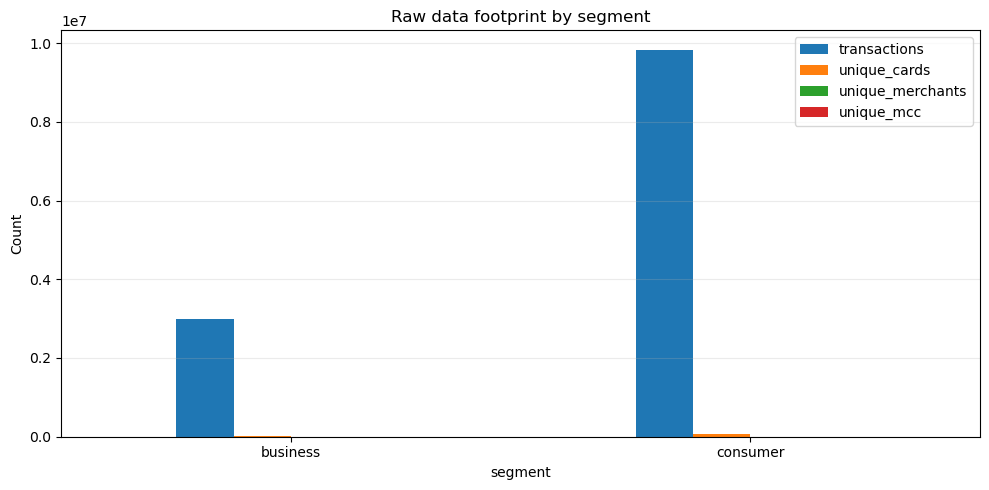

In [7]:
def raw_overview(df, segment):
    temp = df.copy()
    temp["transaction_date"] = pd.to_datetime(temp["transaction_date"])
    return {
        "segment": segment,
        "transactions": len(temp),
        "unique_cards": temp["card_number"].nunique(),
        "unique_merchants": temp["merchant_id"].nunique(),
        "unique_mcc": temp["mcc"].nunique(),
        "min_date": temp["transaction_date"].min().date(),
        "max_date": temp["transaction_date"].max().date(),
        "total_amount_kzt": temp["transaction_amount_kzt"].sum(),
        "median_transaction_amount_kzt": temp["transaction_amount_kzt"].median()
    }

raw_overview_table = pd.DataFrame([
    raw_overview(business_raw, "business"),
    raw_overview(consumer_raw, "consumer")
])

display(raw_overview_table)

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = raw_overview_table.set_index("segment")[["transactions", "unique_cards", "unique_merchants", "unique_mcc"]]
plot_data.plot(kind="bar", ax=ax)
ax.set_title("Raw data footprint by segment")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "01_raw_data_footprint.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.3 Transaction-Level Descriptive EDA

This part compares raw transaction behavior before any aggregation.

We check amount distribution, payment channel, tokenized payments, recurring payments, and transaction time.

,business,consumer
count,2.997593e+06,9.832487e+06
mean,1.565353e+05,5.404542e+04
std,2.528682e+05,1.696546e+05
min,6.700000e+01,1.500000e+01
25%,2.283500e+04,4.172000e+03
50%,7.722400e+04,1.189200e+04
75%,1.960810e+05,3.966500e+04
90%,3.819186e+05,1.179990e+05
99%,1.090845e+06,6.998690e+05
max,4.079930e+07,3.197103e+07


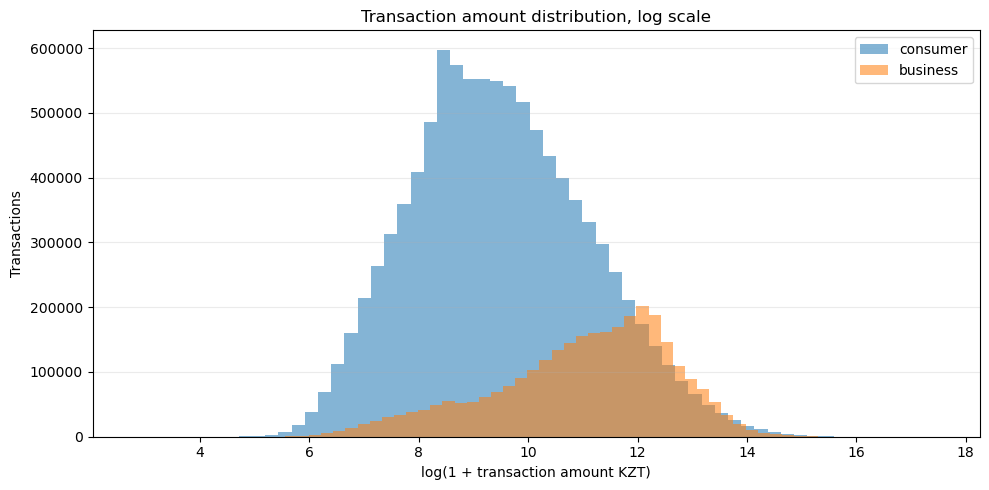

In [8]:
def add_basic_time_fields(df):
    temp = df.copy()
    temp["transaction_timestamp"] = pd.to_datetime(temp["transaction_timestamp"])
    temp["transaction_date"] = pd.to_datetime(temp["transaction_date"])
    temp["hour"] = temp["transaction_timestamp"].dt.hour
    temp["day_of_week"] = temp["transaction_timestamp"].dt.dayofweek
    temp["is_weekend"] = temp["day_of_week"].isin([5, 6]).astype(int)
    temp["month"] = temp["transaction_timestamp"].dt.to_period("M").astype(str)
    return temp

business_desc = add_basic_time_fields(business_raw)
consumer_desc = add_basic_time_fields(consumer_raw)

amount_summary = pd.concat([
    business_desc["transaction_amount_kzt"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).rename("business"),
    consumer_desc["transaction_amount_kzt"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).rename("consumer")
], axis=1)

display(amount_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(consumer_desc["transaction_amount_kzt"]), bins=60, alpha=0.55, label="consumer")
ax.hist(np.log1p(business_desc["transaction_amount_kzt"]), bins=60, alpha=0.55, label="business")
ax.set_title("Transaction amount distribution, log scale")
ax.set_xlabel("log(1 + transaction amount KZT)")
ax.set_ylabel("Transactions")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "02_transaction_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

This chart compares transaction amount distributions for known business cards and consumer cards.

Because transaction amounts are highly skewed, I use `log(1 + transaction amount)` to make the pattern easier to see. The business-card distribution is shifted to the right, which means business cards usually have larger transaction amounts than consumer cards.

This is an important early signal. It shows that monetary behavior can help separate business-like cardholders from normal consumer behavior. Therefore, amount-based features such as `total_amount_kzt`, `median_transaction_amount_kzt`, and `amount_per_active_day_kzt` are reasonable candidates for feature engineering.

,online_transaction_share,pos_transaction_share,tokenized_transaction_share,recurring_transaction_share,weekend_transaction_share,business_hours_transaction_share,night_transaction_share
segment,,,,,,,
business,0.846629,0.153371,0.600008,0.133447,0.124512,0.718752,0.162159
consumer,0.465101,0.534899,0.386253,0.027180,0.347997,0.613085,0.104196


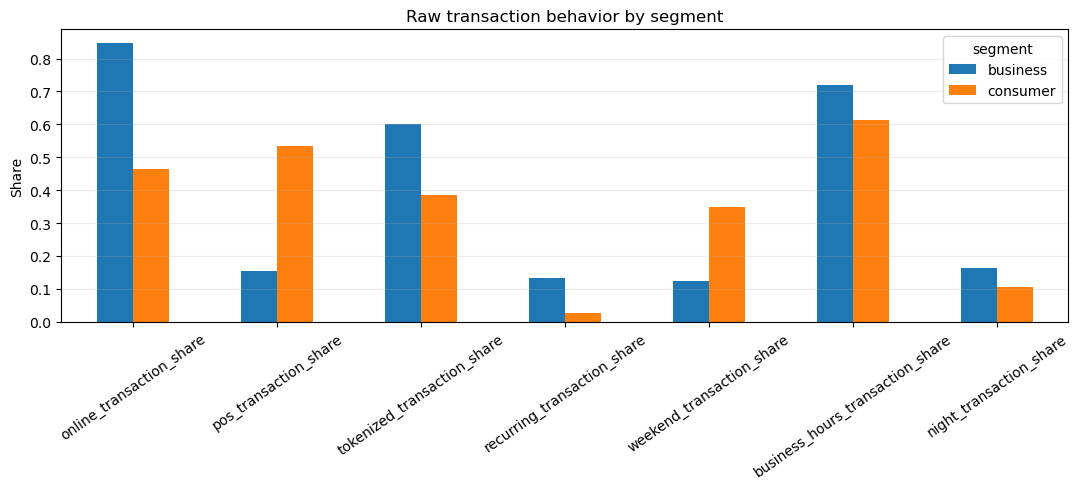

In [9]:
def transaction_behavior_summary(df, segment):
    temp = df.copy()
    channel_clean = temp["channel"].astype(str).str.lower()
    return {
        "segment": segment,
        "online_transaction_share": channel_clean.str.contains("online").mean(),
        "pos_transaction_share": (~channel_clean.str.contains("online")).mean(),
        "tokenized_transaction_share": temp["tokenized"].astype(int).mean(),
        "recurring_transaction_share": temp["is_recurring"].astype(int).mean(),
        "weekend_transaction_share": temp["is_weekend"].mean(),
        "business_hours_transaction_share": temp["hour"].between(9, 18).mean(),
        "night_transaction_share": ((temp["hour"] >= 22) | (temp["hour"] <= 6)).mean(),
    }

transaction_behavior = pd.DataFrame([
    transaction_behavior_summary(business_desc, "business"),
    transaction_behavior_summary(consumer_desc, "consumer")
]).set_index("segment")

display(transaction_behavior)

fig, ax = plt.subplots(figsize=(11, 5))
transaction_behavior.T.plot(kind="bar", ax=ax)
ax.set_title("Raw transaction behavior by segment")
ax.set_ylabel("Share")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "03_raw_transaction_behavior.png", dpi=300, bbox_inches="tight")
plt.show()

The raw behavior comparison shows clear differences between business and consumer transactions.

Known business cards have a much higher online transaction share and tokenized transaction share. They also show more recurring transactions and slightly more business-hour and night activity. Consumer cards have a higher POS transaction share and weekend transaction share.

This supports the idea that payment channel, recurring behavior, and time behavior are useful signals for later feature engineering. These raw patterns are not the final model features yet, but they guide which cardholder-level features should be created.

## 3.4 Merchant Reference Coverage

The merchant table gives additional information such as merchant name, reference MCC, merchant country, and recurring capability.  
Before using it, we check whether transaction merchants are covered by the reference table.

In [10]:
def merchant_coverage(transactions, segment):
    txn_merchants = set(transactions["merchant_id"].astype(str).unique())
    ref_merchants = set(merchants_raw["merchant_id"].astype(str).unique())
    matched = txn_merchants.intersection(ref_merchants)

    return {
        "segment": segment,
        "transaction_unique_merchants": len(txn_merchants),
        "matched_unique_merchants": len(matched),
        "unmatched_unique_merchants": len(txn_merchants - ref_merchants),
        "unique_merchant_match_rate": len(matched) / max(len(txn_merchants), 1),
        "transaction_match_rate": transactions["merchant_id"].astype(str).isin(ref_merchants).mean()
    }

coverage = pd.DataFrame([
    merchant_coverage(business_raw, "business"),
    merchant_coverage(consumer_raw, "consumer")
])

display(coverage)

,segment,transaction_unique_merchants,matched_unique_merchants,unmatched_unique_merchants,unique_merchant_match_rate,transaction_match_rate
0,business,481,481,0,1.0,1.0
1,consumer,2060,2060,0,1.0,1.0


## 3.5 Merchant and MCC Descriptive EDA

This step checks whether business and consumer transactions use merchant categories differently.  
This is important because hidden commercial behavior often appears in where money is spent, not only how much is spent.

,mcc,transactions,amount_kzt,unique_cards,unique_merchants,amount_share,segment
0,7311,271527,114269193463,21515,6,0.243525,business
1,7372,239687,38252432461,18969,6,0.081522,business
2,5968,205593,32580861521,16564,6,0.069435,business
3,4816,189791,30068625328,15233,5,0.064081,business
4,5045,94044,21150514328,11272,5,0.045075,business
5,7399,108963,20749145381,13065,4,0.044220,business
6,7392,93823,17772731639,11236,4,0.037876,business
7,5046,76329,17173920351,9380,7,0.036600,business
8,5111,68603,15461368006,8255,6,0.032951,business
9,4511,94627,14185789552,15013,11,0.030232,business


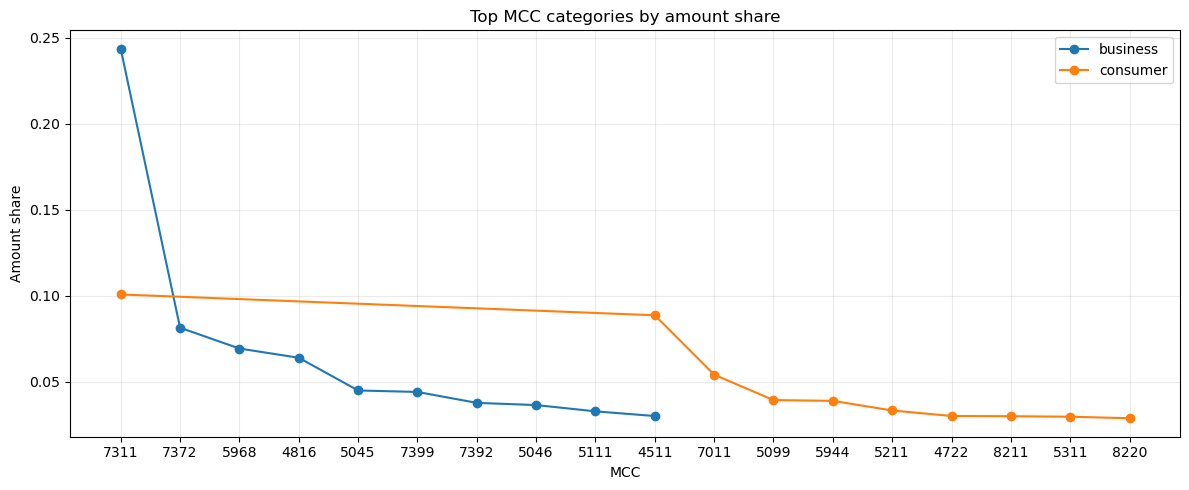

In [11]:
def top_mcc_summary(df, segment, top_n=10):
    temp = df.copy()
    summary = (
        temp.groupby("mcc")
        .agg(
            transactions=("transaction_amount_kzt", "size"),
            amount_kzt=("transaction_amount_kzt", "sum"),
            unique_cards=("card_number", "nunique"),
            unique_merchants=("merchant_id", "nunique")
        )
        .reset_index()
    )
    summary["amount_share"] = summary["amount_kzt"] / summary["amount_kzt"].sum()
    summary["segment"] = segment
    return summary.sort_values("amount_kzt", ascending=False).head(top_n)

top_mcc = pd.concat([
    top_mcc_summary(business_raw, "business"),
    top_mcc_summary(consumer_raw, "consumer")
], ignore_index=True)

display(top_mcc)

fig, ax = plt.subplots(figsize=(12, 5))
for segment in ["business", "consumer"]:
    temp = top_mcc[top_mcc["segment"] == segment].copy()
    ax.plot(temp["mcc"].astype(str), temp["amount_share"], marker="o", label=segment)
ax.set_title("Top MCC categories by amount share")
ax.set_xlabel("MCC")
ax.set_ylabel("Amount share")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "04_top_mcc_amount_share.png", dpi=300, bbox_inches="tight")
plt.show()

The MCC comparison shows that business and consumer transactions are concentrated in different merchant categories.

For business cards, the top MCC categories account for a larger share of total spending. This suggests that business-like behavior is not only about higher spending amount, but also about where the money is spent.

This supports creating merchant and MCC-based features such as `top_mcc_amount_share`, `top_mcc_transaction_share`, `unique_mcc`, and MCC concentration indicators.

### Descriptive EDA conclusion

The descriptive EDA shows the raw structure of the problem before any model features are selected. At this stage, the analysis confirms that the prediction should be made at the cardholder level, not at the transaction level. The raw data also shows that transaction amount, payment channel, recurring behavior, time patterns, merchant usage, and MCC categories all contain potential signals that can help distinguish known business-card behavior from the consumer candidate pool. The merchant reference table is also useful because it adds business context to each transaction. Based on these findings, the next step is diagnostic EDA at the cardholder level, where these raw signals are converted into measurable behavior features and checked more carefully before modeling.

# 4. Diagnostic EDA 

Now we build a **broad candidate cardholder table** only for diagnosis.  
This table is not yet the final model feature set.

The goal is to prove which behavior signals separate known business cards from the consumer candidate pool.

## 4.1 Enrich Transactions

Merchant reference data is joined to raw transactions.  
Then simple behavior flags are created: online/POS, weekend, business hours, night, recurring-capable merchant, and month.

In [12]:
def safe_divide(a, b):
    return np.where(np.asarray(b) == 0, 0, np.asarray(a) / np.asarray(b))

def enrich_transactions(df, merchants):
    temp = df.copy()
    temp["card_number"] = temp["card_number"].astype(str)
    temp["merchant_id"] = temp["merchant_id"].astype(str)
    temp["mcc"] = temp["mcc"].astype(str)
    temp["transaction_timestamp"] = pd.to_datetime(temp["transaction_timestamp"])
    temp["transaction_date"] = pd.to_datetime(temp["transaction_date"])

    ref = merchants.copy()
    ref["merchant_id"] = ref["merchant_id"].astype(str)
    ref["mcc"] = ref["mcc"].astype(str)
    ref = ref.rename(columns={"mcc": "reference_mcc"})

    temp = temp.merge(ref, on="merchant_id", how="left")

    temp["mcc_for_analysis"] = temp["reference_mcc"].fillna(temp["mcc"]).astype(str)
    temp["recurring_capable"] = temp["recurring_capable"].fillna(False).astype(bool)

    channel_clean = temp["channel"].astype(str).str.lower()
    temp["is_online"] = channel_clean.str.contains("online").astype(int)
    temp["is_pos"] = (1 - temp["is_online"]).astype(int)

    temp["hour"] = temp["transaction_timestamp"].dt.hour
    temp["day_of_week"] = temp["transaction_timestamp"].dt.dayofweek
    temp["is_weekend"] = temp["day_of_week"].isin([5, 6]).astype(int)
    temp["is_business_hours"] = temp["hour"].between(9, 18).astype(int)
    temp["is_night"] = ((temp["hour"] >= 22) | (temp["hour"] <= 6)).astype(int)
    temp["year_month"] = temp["transaction_timestamp"].dt.to_period("M").astype(str)

    return temp

business_txn = enrich_transactions(business_raw, merchants_raw)
consumer_txn = enrich_transactions(consumer_raw, merchants_raw)

enrichment_check = pd.DataFrame([
    {
        "segment": "business",
        "rows": len(business_txn),
        "missing_merchant_name": int(business_txn["merchant_name"].isna().sum()),
        "missing_reference_mcc": int(business_txn["reference_mcc"].isna().sum()),
        "missing_recurring_capable": int(business_txn["recurring_capable"].isna().sum()),
    },
    {
        "segment": "consumer",
        "rows": len(consumer_txn),
        "missing_merchant_name": int(consumer_txn["merchant_name"].isna().sum()),
        "missing_reference_mcc": int(consumer_txn["reference_mcc"].isna().sum()),
        "missing_recurring_capable": int(consumer_txn["recurring_capable"].isna().sum()),
    }
])

display(enrichment_check)

,segment,rows,missing_merchant_name,missing_reference_mcc,missing_recurring_capable
0,business,2997593,0,0,0
1,consumer,9832487,0,0,0


## 4.2 Build Broad Candidate Cardholder Features

This is a diagnostic feature table.  
It contains more candidate behavior signals than the final model may need.

We build it before feature selection so we can compare the evidence.

In [13]:
def build_candidate_cardholder_features(data, segment):
    temp = data.copy()

    amount_flags = {
        "online_amount": "is_online",
        "pos_amount": "is_pos",
        "tokenized_amount": "tokenized",
        "recurring_amount": "is_recurring",
        "recurring_capable_amount": "recurring_capable",
        "weekend_amount": "is_weekend",
        "business_hours_amount": "is_business_hours",
        "night_amount": "is_night",
    }

    for new_col, flag_col in amount_flags.items():
        temp[new_col] = temp["transaction_amount_kzt"] * temp[flag_col].astype(int)

    card = (
        temp.groupby("card_number")
        .agg(
            total_transactions=("transaction_amount_kzt", "size"),
            total_amount_kzt=("transaction_amount_kzt", "sum"),
            avg_transaction_amount_kzt=("transaction_amount_kzt", "mean"),
            median_transaction_amount_kzt=("transaction_amount_kzt", "median"),
            min_transaction_amount_kzt=("transaction_amount_kzt", "min"),
            max_transaction_amount_kzt=("transaction_amount_kzt", "max"),
            active_days=("transaction_date", "nunique"),
            active_months=("year_month", "nunique"),
            unique_merchants=("merchant_id", "nunique"),
            unique_mcc=("mcc_for_analysis", "nunique"),
            unique_transaction_countries=("country", "nunique"),
            unique_merchant_countries=("merchant_country", "nunique"),
            online_transaction_share=("is_online", "mean"),
            pos_transaction_share=("is_pos", "mean"),
            tokenized_transaction_share=("tokenized", "mean"),
            recurring_transaction_share=("is_recurring", "mean"),
            recurring_capable_merchant_share=("recurring_capable", "mean"),
            weekend_transaction_share=("is_weekend", "mean"),
            business_hours_transaction_share=("is_business_hours", "mean"),
            night_transaction_share=("is_night", "mean"),
            online_amount=("online_amount", "sum"),
            pos_amount=("pos_amount", "sum"),
            tokenized_amount=("tokenized_amount", "sum"),
            recurring_amount=("recurring_amount", "sum"),
            recurring_capable_amount=("recurring_capable_amount", "sum"),
            weekend_amount=("weekend_amount", "sum"),
            business_hours_amount=("business_hours_amount", "sum"),
            night_amount=("night_amount", "sum"),
            bank_name=("bank_name", "first"),
            card_tier=("card_tier", "first")
        )
        .reset_index()
    )

    card["amount_per_active_day_kzt"] = safe_divide(card["total_amount_kzt"], card["active_days"])
    card["transactions_per_active_day"] = safe_divide(card["total_transactions"], card["active_days"])

    for amount_col in amount_flags.keys():
        share_col = amount_col.replace("_amount", "_amount_share")
        card[share_col] = safe_divide(card[amount_col], card["total_amount_kzt"])

    # MCC concentration by amount
    mcc_amount = (
        temp.groupby(["card_number", "mcc_for_analysis"])
        .agg(mcc_amount_kzt=("transaction_amount_kzt", "sum"))
        .reset_index()
    )
    total_amount = card[["card_number", "total_amount_kzt"]]
    mcc_amount = mcc_amount.merge(total_amount, on="card_number", how="left")
    mcc_amount["mcc_amount_share"] = safe_divide(mcc_amount["mcc_amount_kzt"], mcc_amount["total_amount_kzt"])

    mcc_features = (
        mcc_amount.groupby("card_number")
        .agg(
            top_mcc_amount_share=("mcc_amount_share", "max"),
            mcc_amount_hhi=("mcc_amount_share", lambda s: float(np.sum(np.square(s))))
        )
        .reset_index()
    )

    # Merchant concentration by amount
    merchant_amount = (
        temp.groupby(["card_number", "merchant_id"])
        .agg(merchant_amount_kzt=("transaction_amount_kzt", "sum"))
        .reset_index()
    )
    merchant_amount = merchant_amount.merge(total_amount, on="card_number", how="left")
    merchant_amount["merchant_amount_share"] = safe_divide(merchant_amount["merchant_amount_kzt"], merchant_amount["total_amount_kzt"])

    merchant_features = (
        merchant_amount.groupby("card_number")
        .agg(
            top_merchant_amount_share=("merchant_amount_share", "max"),
            merchant_amount_hhi=("merchant_amount_share", lambda s: float(np.sum(np.square(s))))
        )
        .reset_index()
    )

    # Monthly stability
    monthly = (
        temp.groupby(["card_number", "year_month"])
        .agg(monthly_amount_kzt=("transaction_amount_kzt", "sum"))
        .reset_index()
    )
    monthly_features = (
        monthly.groupby("card_number")
        .agg(
            monthly_amount_mean=("monthly_amount_kzt", "mean"),
            monthly_amount_std=("monthly_amount_kzt", "std")
        )
        .reset_index()
    )
    monthly_features["monthly_amount_std"] = monthly_features["monthly_amount_std"].fillna(0)
    monthly_features["monthly_amount_cv"] = safe_divide(
        monthly_features["monthly_amount_std"], monthly_features["monthly_amount_mean"]
    )

    card = card.merge(mcc_features, on="card_number", how="left")
    card = card.merge(merchant_features, on="card_number", how="left")
    card = card.merge(monthly_features[["card_number", "monthly_amount_cv"]], on="card_number", how="left")

    # Raw amount columns are helper columns. The model uses shares and totals instead.
    card = card.drop(columns=list(amount_flags.keys()))
    card["segment"] = segment

    return card

business_cards = build_candidate_cardholder_features(business_txn, "business")
consumer_cards = build_candidate_cardholder_features(consumer_txn, "consumer")

cardholder_eda = pd.concat([business_cards, consumer_cards], ignore_index=True)

print("Cardholder EDA table:", cardholder_eda.shape)
display(cardholder_eda.head())

Cardholder EDA table: (105000, 39)


,card_number,total_transactions,total_amount_kzt,avg_transaction_amount_kzt,median_transaction_amount_kzt,min_transaction_amount_kzt,max_transaction_amount_kzt,active_days,active_months,unique_merchants,unique_mcc,unique_transaction_countries,unique_merchant_countries,online_transaction_share,pos_transaction_share,tokenized_transaction_share,recurring_transaction_share,recurring_capable_merchant_share,weekend_transaction_share,business_hours_transaction_share,night_transaction_share,bank_name,card_tier,amount_per_active_day_kzt,transactions_per_active_day,online_amount_share,pos_amount_share,tokenized_amount_share,recurring_amount_share,recurring_capable_amount_share,weekend_amount_share,business_hours_amount_share,night_amount_share,top_mcc_amount_share,mcc_amount_hhi,top_merchant_amount_share,merchant_amount_hhi,monthly_amount_cv,segment
0,5100610003025081,178,9651486,54221.831461,14499.0,659,745914,105,6,9,9,9,3,0.865169,0.134831,0.646067,0.067416,0.140449,0.101124,0.758427,0.112360,Halyk,Business,91918.914286,1.695238,0.924648,0.075352,0.577319,0.269754,0.457044,0.060006,0.638001,0.283847,0.252958,0.189605,0.252958,0.189605,0.229397,business
1,5100610003044611,106,14353608,135411.396226,67810.0,604,1483178,80,6,18,17,5,3,0.905660,0.094340,0.632075,0.169811,0.452830,0.122642,0.698113,0.179245,Halyk,Business,179420.100000,1.325000,0.911219,0.088781,0.535689,0.225478,0.402243,0.118793,0.544926,0.229459,0.271315,0.163808,0.271315,0.152446,0.339206,business
2,5100610003860784,148,13102356,88529.432432,56445.0,262,652796,90,6,8,8,3,2,0.891892,0.108108,0.655405,0.040541,0.067568,0.114865,0.844595,0.047297,Halyk,Business,145581.733333,1.644444,0.909021,0.090979,0.653922,0.160647,0.180222,0.102670,0.724384,0.167023,0.337584,0.218715,0.337584,0.218715,0.171563,business
3,5100610008756482,196,27341119,139495.505102,98362.5,1208,1286163,101,6,27,18,10,6,0.826531,0.173469,0.653061,0.061224,0.127551,0.142857,0.750000,0.086735,Halyk,Business,270704.148515,1.940594,0.825088,0.174912,0.681424,0.076643,0.150542,0.151772,0.707220,0.096361,0.580140,0.355437,0.580140,0.355385,0.229991,business
4,5100610013466473,120,16439793,136998.275000,46989.0,326,982511,80,6,19,19,5,5,0.925000,0.075000,0.600000,0.150000,0.216667,0.083333,0.758333,0.175000,Halyk,Business,205497.412500,1.500000,0.965896,0.034104,0.431508,0.426691,0.487241,0.143693,0.551378,0.431953,0.376931,0.215686,0.376931,0.215686,0.355211,business


## 4.3 Cardholder-Level Descriptive Summary

This confirms that the cardholder-level aggregation works and shows the main portfolio differences.

In [14]:
cardholder_summary = (
    cardholder_eda
    .groupby("segment")
    .agg(
        cardholders=("card_number", "count"),
        median_total_amount_kzt=("total_amount_kzt", "median"),
        median_transaction_amount_kzt=("median_transaction_amount_kzt", "median"),
        median_amount_per_active_day_kzt=("amount_per_active_day_kzt", "median"),
        median_total_transactions=("total_transactions", "median"),
        median_unique_merchants=("unique_merchants", "median"),
        median_unique_mcc=("unique_mcc", "median"),
        median_online_amount_share=("online_amount_share", "median"),
        median_recurring_amount_share=("recurring_amount_share", "median"),
        median_top_mcc_amount_share=("top_mcc_amount_share", "median")
    )
    .reset_index()
)

display(cardholder_summary)

,segment,cardholders,median_total_amount_kzt,median_transaction_amount_kzt,median_amount_per_active_day_kzt,median_total_transactions,median_unique_merchants,median_unique_mcc,median_online_amount_share,median_recurring_amount_share,median_top_mcc_amount_share
0,business,25000,17714892.5,84558.5,229641.074996,119.0,16.0,15.0,0.885180,0.26078,0.371843
1,consumer,80000,2976294.0,9673.5,36706.366080,120.0,37.0,32.0,0.442655,0.00000,0.244962


## 4.4 Diagnostic Feature Evidence

Now we test candidate features one by one.

For each feature we calculate:

- business median;
- consumer median;
- standardized gap;
- univariate ROC-AUC.

The standardized gap is:

$$
Gap_j =
\frac{median(x_j \mid business) - median(x_j \mid consumer)}
{IQR(x_j)}
$$

The univariate ROC-AUC checks whether one feature alone can help rank business cards above consumer cards.  
This is not the final model. It is only feature evidence.

In [15]:
candidate_features = [
    "total_transactions",
    "total_amount_kzt",
    "avg_transaction_amount_kzt",
    "median_transaction_amount_kzt",
    "amount_per_active_day_kzt",
    "transactions_per_active_day",
    "active_days",
    "active_months",
    "unique_merchants",
    "unique_mcc",
    "unique_transaction_countries",
    "unique_merchant_countries",
    "online_transaction_share",
    "pos_transaction_share",
    "tokenized_transaction_share",
    "recurring_transaction_share",
    "recurring_capable_merchant_share",
    "weekend_transaction_share",
    "business_hours_transaction_share",
    "night_transaction_share",
    "online_amount_share",
    "pos_amount_share",
    "tokenized_amount_share",
    "recurring_amount_share",
    "recurring_capable_amount_share",
    "weekend_amount_share",
    "business_hours_amount_share",
    "night_amount_share",
    "top_mcc_amount_share",
    "mcc_amount_hhi",
    "top_merchant_amount_share",
    "merchant_amount_hhi",
    "monthly_amount_cv",
]

feature_groups = {
    "total_transactions": "Monetary and frequency",
    "total_amount_kzt": "Monetary and frequency",
    "avg_transaction_amount_kzt": "Monetary and frequency",
    "median_transaction_amount_kzt": "Monetary and frequency",
    "amount_per_active_day_kzt": "Monetary and frequency",
    "transactions_per_active_day": "Monetary and frequency",
    "active_days": "Monetary and frequency",
    "active_months": "Monetary and frequency",
    "unique_merchants": "Merchant and MCC",
    "unique_mcc": "Merchant and MCC",
    "unique_transaction_countries": "Merchant and MCC",
    "unique_merchant_countries": "Merchant and MCC",
    "online_transaction_share": "Payment behavior",
    "pos_transaction_share": "Payment behavior",
    "tokenized_transaction_share": "Payment behavior",
    "recurring_transaction_share": "Payment behavior",
    "recurring_capable_merchant_share": "Payment behavior",
    "online_amount_share": "Payment behavior",
    "pos_amount_share": "Payment behavior",
    "tokenized_amount_share": "Payment behavior",
    "recurring_amount_share": "Payment behavior",
    "recurring_capable_amount_share": "Payment behavior",
    "weekend_transaction_share": "Time behavior",
    "business_hours_transaction_share": "Time behavior",
    "night_transaction_share": "Time behavior",
    "weekend_amount_share": "Time behavior",
    "business_hours_amount_share": "Time behavior",
    "night_amount_share": "Time behavior",
    "top_mcc_amount_share": "Merchant and MCC",
    "mcc_amount_hhi": "Merchant and MCC",
    "top_merchant_amount_share": "Merchant and MCC",
    "merchant_amount_hhi": "Merchant and MCC",
    "monthly_amount_cv": "Time behavior",
}

business_meaning = {
    "total_transactions": "Overall transaction frequency",
    "total_amount_kzt": "Total spending volume over the period",
    "avg_transaction_amount_kzt": "Average ticket size",
    "median_transaction_amount_kzt": "Typical ticket size",
    "amount_per_active_day_kzt": "Spending intensity on active days",
    "transactions_per_active_day": "Transaction intensity on active days",
    "active_days": "Number of active transaction days",
    "active_months": "Activity continuity across months",
    "unique_merchants": "Merchant diversity",
    "unique_mcc": "Category diversity",
    "unique_transaction_countries": "Cross-country transaction behavior",
    "unique_merchant_countries": "Merchant registration country diversity",
    "online_transaction_share": "Digital transaction channel share",
    "pos_transaction_share": "Physical POS transaction share",
    "tokenized_transaction_share": "Tokenized wallet usage by transactions",
    "recurring_transaction_share": "Merchant-initiated regular transaction share",
    "recurring_capable_merchant_share": "Share of transactions at recurring-capable merchants",
    "online_amount_share": "Digital spending share",
    "pos_amount_share": "Physical POS spending share",
    "tokenized_amount_share": "Tokenized wallet spending share",
    "recurring_amount_share": "Regular payment spending share",
    "recurring_capable_amount_share": "Spending at recurring-capable merchants",
    "weekend_transaction_share": "Weekend activity share",
    "business_hours_transaction_share": "Work-time activity share",
    "night_transaction_share": "Night activity share",
    "weekend_amount_share": "Weekend spending share",
    "business_hours_amount_share": "Work-time spending share",
    "night_amount_share": "Night spending share",
    "top_mcc_amount_share": "Share of spending in the largest MCC category",
    "mcc_amount_hhi": "Spending concentration across MCC categories",
    "top_merchant_amount_share": "Share of spending at the largest merchant",
    "merchant_amount_hhi": "Spending concentration across merchants",
    "monthly_amount_cv": "Month-to-month spending volatility",
}

evidence_rows = []
y = (cardholder_eda["segment"] == "business").astype(int)

for feature in candidate_features:
    x = cardholder_eda[feature].replace([np.inf, -np.inf], np.nan).fillna(0)
    business_median = business_cards[feature].median()
    consumer_median = consumer_cards[feature].median()
    iqr = x.quantile(0.75) - x.quantile(0.25)
    gap = 0 if iqr == 0 else (business_median - consumer_median) / iqr

    try:
        auc = roc_auc_score(y, x)
        # If a feature is higher for consumers, invert AUC only for separation strength.
        separation_auc = max(auc, 1 - auc)
    except ValueError:
        auc = np.nan
        separation_auc = np.nan

    evidence_rows.append({
        "feature": feature,
        "feature_group": feature_groups.get(feature, "Other"),
        "business_median": business_median,
        "consumer_median": consumer_median,
        "standardized_gap": gap,
        "univariate_auc_raw_direction": auc,
        "separation_auc": separation_auc,
        "business_meaning": business_meaning.get(feature, "")
    })

feature_evidence = (
    pd.DataFrame(evidence_rows)
    .sort_values("separation_auc", ascending=False)
    .reset_index(drop=True)
)

display(feature_evidence.head(20))

feature_evidence.to_csv(OUTPUT_FOLDER / "feature_evidence_and_justification.csv", index=False)

,feature,feature_group,business_median,consumer_median,standardized_gap,univariate_auc_raw_direction,separation_auc,business_meaning
0,pos_amount_share,Payment behavior,1.148200e-01,5.573454e-01,-1.174343,0.011063,0.988937,Physical POS spending share
1,online_amount_share,Payment behavior,8.851800e-01,4.426546e-01,1.174343,0.988937,0.988937,Digital spending share
2,pos_transaction_share,Payment behavior,1.475410e-01,5.528455e-01,-1.213233,0.012345,0.987655,Physical POS transaction share
3,online_transaction_share,Payment behavior,8.524590e-01,4.471545e-01,1.213233,0.987655,0.987655,Digital transaction channel share
4,tokenized_transaction_share,Payment behavior,5.949367e-01,3.855422e-01,1.918132,0.981943,0.981943,Tokenized wallet usage by transactions
5,recurring_amount_share,Payment behavior,2.607804e-01,0.000000e+00,2.156571,0.981825,0.981825,Regular payment spending share
6,weekend_transaction_share,Time behavior,1.241379e-01,3.502304e-01,-1.342015,0.019838,0.980162,Weekend activity share
7,recurring_transaction_share,Payment behavior,1.343284e-01,0.000000e+00,1.410448,0.949539,0.949539,Merchant-initiated regular transaction share
8,night_amount_share,Time behavior,2.875365e-01,7.379405e-02,1.502676,0.944745,0.944745,Night spending share
9,weekend_amount_share,Time behavior,1.398426e-01,3.410897e-01,-1.021213,0.061029,0.938971,Weekend spending share


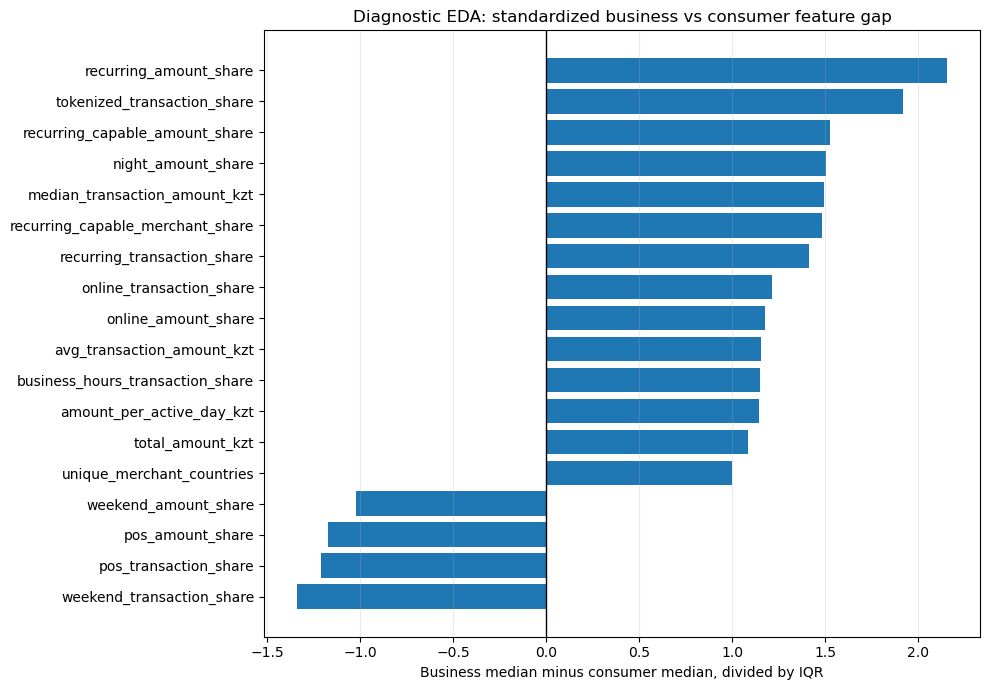

In [16]:
# Visual diagnostic: standardized feature gap

plot_table = (
    feature_evidence
    .assign(abs_gap=lambda d: d["standardized_gap"].abs())
    .sort_values("abs_gap", ascending=False)
    .head(18)
    .sort_values("standardized_gap")
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_table["feature"], plot_table["standardized_gap"])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Diagnostic EDA: standardized business vs consumer feature gap")
ax.set_xlabel("Business median minus consumer median, divided by IQR")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "05_standardized_feature_gap.png", dpi=300, bbox_inches="tight")
plt.show()

This diagnostic chart shows which cardholder-level features are different between known business cards and consumer cards.

So, bars on the **right side** mean the feature is higher for business cards.  
Bars on the **left side** mean the feature is higher for consumer cards.

The result shows that business cards have stronger recurring amount share, tokenized payment share, recurring-capable merchant usage, online spending, higher transaction amount, and business-hour activity. Consumer cards show higher POS and weekend transaction behavior.

This chart is important because it proves that the selected features are not random. They are selected because they show measurable behavioral differences between known business cards and the consumer candidate pool.

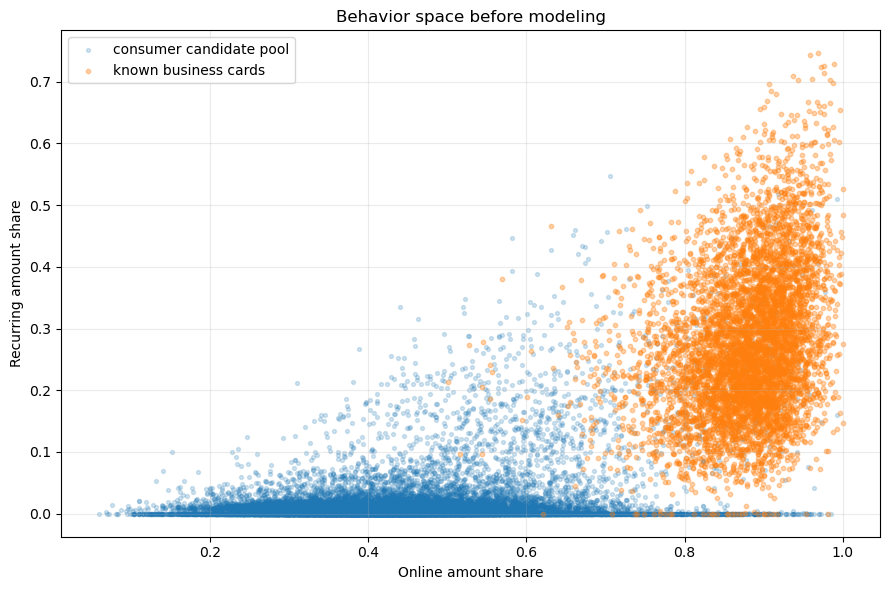

In [17]:
# Visual diagnostic: behavior space

plot_business = business_cards.sample(min(6000, len(business_cards)), random_state=RANDOM_STATE)
plot_consumer = consumer_cards.sample(min(20000, len(consumer_cards)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    plot_consumer["online_amount_share"],
    plot_consumer["recurring_amount_share"],
    s=8,
    alpha=0.20,
    label="consumer candidate pool"
)
ax.scatter(
    plot_business["online_amount_share"],
    plot_business["recurring_amount_share"],
    s=10,
    alpha=0.35,
    label="known business cards"
)
ax.set_title("Behavior space before modeling")
ax.set_xlabel("Online amount share")
ax.set_ylabel("Recurring amount share")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "06_behavior_space_before_modeling.png", dpi=300, bbox_inches="tight")
plt.show()

This scatter plot shows the behavior space before model training. Each point represents one cardholder-level profile.

The x-axis is `online_amount_share`, and the y-axis is `recurring_amount_share`. These two features were chosen for the visual because they are easy to interpret and showed strong differences in the diagnostic EDA.

Known business cards are concentrated more toward the upper-right area, meaning they usually have higher online spending and higher recurring payment share. Most consumer cards are concentrated near the lower part of the chart, especially with low recurring amount share.

This visual supports the feature engineering decision: online behavior and recurring payment behavior are useful signals for detecting business-like cardholders. It also shows that the model is not using random variables; it is learning from visible behavioral separation.

In [18]:
# Feature group evidence summary

group_evidence = (
    feature_evidence
    .groupby("feature_group")
    .agg(
        number_of_candidate_features=("feature", "count"),
        median_separation_auc=("separation_auc", "median"),
        max_separation_auc=("separation_auc", "max"),
        median_abs_standardized_gap=("standardized_gap", lambda s: s.abs().median())
    )
    .reset_index()
    .sort_values("median_separation_auc", ascending=False)
)

display(group_evidence)

,feature_group,number_of_candidate_features,median_separation_auc,max_separation_auc,median_abs_standardized_gap
2,Payment behavior,10,0.981884,0.988937,1.311840
3,Time behavior,7,0.837345,0.980162,1.021213
0,Merchant and MCC,8,0.814331,0.913452,0.846016
1,Monetary and frequency,8,0.737614,0.924336,0.671722


The feature group summary shows that all four groups contain useful signal, but their strength is different.

Payment behavior has the strongest separation, followed by time behavior, merchant/MCC behavior, and monetary/frequency behavior. This means that business-like cardholders are not identified only by how much they spend. Their payment style, transaction timing, and merchant category patterns also matter.

Based on this result, the final model uses features from multiple groups: monetary and frequency, payment behavior, merchant/MCC behavior, and time behavior.

### Diagnostic EDA conclusion

The diagnostic EDA confirms that the final feature set should cover four main behavior groups. First, **monetary and frequency features** show how much, how often, and how intensively each cardholder spends. Second, **payment behavior features** capture online, POS, tokenized, recurring, and recurring-capable merchant usage. Third, **merchant and MCC behavior features** describe merchant diversity, MCC diversity, and spending concentration. Finally, **time behavior features** capture weekend, business-hour, night, and month-to-month spending patterns. Based on this evidence, the model features are selected from real behavioral differences between known business cards and consumer cards, not randomly.

# 5. Feature Selection Decision

Now we select the model features.

Selection rule:

1. Use only cardholder-level behavior features.
2. Keep features that have business meaning.
3. Cover all four feature groups from the diagnostic EDA.
4. Do not use raw identifiers as model inputs.
5. Do not use `card_tier` as a model feature because it can reflect the existing product type instead of hidden behavior.

The final model still outputs one score per `card_number`.

In [19]:
selected_features = [
    # Monetary and frequency
    "total_transactions",
    "total_amount_kzt",
    "avg_transaction_amount_kzt",
    "median_transaction_amount_kzt",
    "amount_per_active_day_kzt",
    "transactions_per_active_day",
    "active_days",
    "active_months",

    # Payment behavior
    "online_transaction_share",
    "pos_transaction_share",
    "tokenized_transaction_share",
    "recurring_transaction_share",
    "recurring_capable_merchant_share",
    "online_amount_share",
    "pos_amount_share",
    "tokenized_amount_share",
    "recurring_amount_share",
    "recurring_capable_amount_share",

    # Merchant and MCC behavior
    "unique_merchants",
    "unique_mcc",
    "unique_transaction_countries",
    "unique_merchant_countries",
    "top_mcc_amount_share",
    "mcc_amount_hhi",
    "top_merchant_amount_share",
    "merchant_amount_hhi",

    # Time behavior
    "weekend_transaction_share",
    "business_hours_transaction_share",
    "night_transaction_share",
    "weekend_amount_share",
    "business_hours_amount_share",
    "night_amount_share",
    "monthly_amount_cv",
]

selected_feature_table = (
    pd.DataFrame({"feature": selected_features})
    .merge(feature_evidence, on="feature", how="left")
    .sort_values(["feature_group", "separation_auc"], ascending=[True, False])
)

display(selected_feature_table[[
    "feature",
    "feature_group",
    "business_meaning",
    "standardized_gap",
    "separation_auc"
]])

selected_feature_table.to_csv(OUTPUT_FOLDER / "selected_features_with_evidence.csv", index=False)

print("Number of selected model features:", len(selected_features))

,feature,feature_group,business_meaning,standardized_gap,separation_auc
19,unique_mcc,Merchant and MCC,Category diversity,-0.850000,0.913452
18,unique_merchants,Merchant and MCC,Merchant diversity,-0.875000,0.884065
21,unique_merchant_countries,Merchant and MCC,Merchant registration country diversity,1.000000,0.827109
20,unique_transaction_countries,Merchant and MCC,Cross-country transaction behavior,-1.000000,0.820217
25,merchant_amount_hhi,Merchant and MCC,Spending concentration across merchants,0.842033,0.808446
23,mcc_amount_hhi,Merchant and MCC,Spending concentration across MCC categories,0.786632,0.792369
24,top_merchant_amount_share,Merchant and MCC,Share of spending at the largest merchant,0.663783,0.748656
22,top_mcc_amount_share,Merchant and MCC,Share of spending in the largest MCC category,0.596533,0.725017
3,median_transaction_amount_kzt,Monetary and frequency,Typical ticket size,1.492856,0.924336
2,avg_transaction_amount_kzt,Monetary and frequency,Average ticket size,1.154512,0.916414


Number of selected model features: 33


# 6. Modeling Strategy

The consumer dataset does not have true hidden-business labels.  
A normal supervised classifier would incorrectly assume all consumers are true negatives.

Therefore, the main model is a **repeated Positive-Unlabeled ranking model**.

For every run:

1. Use known business cards as positive examples.
2. Sample consumer cards as a temporary comparison group.
3. Train a tabular ranking classifier.
4. Score all consumer cards.
5. Average scores across repeated runs.

We also train two supporting checks:

- a business-profile similarity baseline;
- a Logistic Regression benchmark.

These are used for validation and explainability, not as manually weighted final score components.

## 6.1 Train / Validation Split

We keep a holdout part of the known business cards for proxy validation.  
This helps check whether the model can still recognize business-like behavior it did not train on.

In [20]:
business_train, business_holdout = train_test_split(
    business_cards,
    test_size=0.25,
    random_state=RANDOM_STATE
)

consumer_train_pool, consumer_check_pool = train_test_split(
    consumer_cards,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Business train:", len(business_train))
print("Business holdout:", len(business_holdout))
print("Consumer train pool:", len(consumer_train_pool))
print("Consumer check pool:", len(consumer_check_pool))

Business train: 18750
Business holdout: 6250
Consumer train pool: 60000
Consumer check pool: 20000


The split creates separate training and validation groups.

The model trains on 18,750 known business cards and samples from 60,000 consumer candidate cards. The holdout set contains 6,250 known business cards and 20,000 consumer cards for proxy validation. This separation helps reduce the risk of evaluating the model on the same examples it learned from.

## 6.2 Business Similarity Baseline

This is a simple sanity check.  
It scores consumer cards by distance to the known business behavior profile.

In [21]:
# Similarity score based on robust-scaled distance to business median profile

scaler = RobustScaler()
all_for_scale = pd.concat([
    business_train[selected_features],
    consumer_train_pool[selected_features]
], ignore_index=True).replace([np.inf, -np.inf], np.nan).fillna(0)

scaler.fit(all_for_scale)

business_scaled = scaler.transform(business_train[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0))
business_center = np.median(business_scaled, axis=0)

def business_similarity_score(df):
    x = df[selected_features].replace([np.inf, -np.inf], np.nan).fillna(0)
    x_scaled = scaler.transform(x)
    distance = np.sqrt(np.mean((x_scaled - business_center) ** 2, axis=1))
    raw_score = 1 / (1 + distance)
    return raw_score

similarity_validation = pd.concat([business_holdout, consumer_check_pool], ignore_index=True)
similarity_y = np.r_[np.ones(len(business_holdout)), np.zeros(len(consumer_check_pool))]
similarity_score = business_similarity_score(similarity_validation)

similarity_auc = roc_auc_score(similarity_y, similarity_score)
similarity_pr_auc = average_precision_score(similarity_y, similarity_score)

print("Business similarity baseline ROC-AUC:", round(similarity_auc, 4))
print("Business similarity baseline PR-AUC:", round(similarity_pr_auc, 4))

Business similarity baseline ROC-AUC: 0.9704
Business similarity baseline PR-AUC: 0.9658


The business similarity baseline already gives strong ranking performance, with ROC-AUC around 0.9704 and PR-AUC around 0.9658.

This result is important because it shows that the engineered behavior features contain real separation signal even before using a stronger model. In other words, known business cards are measurably closer to the business behavior profile than the sampled consumer comparison group.

Since this baseline is simple and explainable, it also supports the business logic of the final model.

## 6.3 Logistic Regression Benchmark

Logistic Regression is used as a transparent benchmark.  
It helps confirm whether the signal is not only coming from the gradient boosting model.

In [22]:
# Use one balanced proxy sample for the benchmark.
n_neg = min(len(consumer_train_pool), len(business_train))
consumer_sample_lr = consumer_train_pool.sample(n=n_neg, random_state=RANDOM_STATE)

lr_train = pd.concat([business_train, consumer_sample_lr], ignore_index=True)
lr_y_train = np.r_[np.ones(len(business_train)), np.zeros(len(consumer_sample_lr))]

lr_validation = pd.concat([business_holdout, consumer_check_pool], ignore_index=True)
lr_y_val = np.r_[np.ones(len(business_holdout)), np.zeros(len(consumer_check_pool))]

logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=600, class_weight="balanced", random_state=RANDOM_STATE))
])

logreg_model.fit(lr_train[selected_features], lr_y_train)
logreg_val_score = logreg_model.predict_proba(lr_validation[selected_features])[:, 1]

logreg_auc = roc_auc_score(lr_y_val, logreg_val_score)
logreg_pr_auc = average_precision_score(lr_y_val, logreg_val_score)

print("Logistic Regression benchmark ROC-AUC:", round(logreg_auc, 4))
print("Logistic Regression benchmark PR-AUC:", round(logreg_pr_auc, 4))

Logistic Regression benchmark ROC-AUC: 1.0
Logistic Regression benchmark PR-AUC: 1.0


The Logistic Regression benchmark performs very strongly on the proxy validation set.

This confirms that the engineered features already contain a clear signal between known business cards and sampled consumer comparison cards. The result also shows that the final model is not relying only on complex non-linear behavior; even a transparent linear model can identify much of the separation.

However, Logistic Regression is kept as a benchmark. The final model still uses repeated Positive-Unlabeled sampling with gradient boosting because it is more flexible and more stable for ranking the unlabeled consumer candidate pool.

## 6.4 Main Model: Repeated Positive-Unlabeled Hist Gradient Boosting

Hist Gradient Boosting is selected as the main model because:

- the data is tabular;
- the behavior patterns are non-linear;
- the model works well with mixed engineered numerical features;
- it is available in scikit-learn, so the notebook remains reproducible.

The final consumer score is the average score across repeated PU runs.

In [23]:
R = 15
consumer_sample_size = min(len(consumer_train_pool), len(business_train))

validation_set = pd.concat([business_holdout, consumer_check_pool], ignore_index=True)
validation_y = np.r_[np.ones(len(business_holdout)), np.zeros(len(consumer_check_pool))]

pu_models = []
pu_run_scores = []
consumer_score_runs = []

for run in range(R):
    run_seed = RANDOM_STATE + run

    consumer_sample = consumer_train_pool.sample(
        n=consumer_sample_size,
        random_state=run_seed
    )

    train_data = pd.concat([business_train, consumer_sample], ignore_index=True)
    train_y = np.r_[np.ones(len(business_train)), np.zeros(len(consumer_sample))]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            max_iter=140,
            learning_rate=0.06,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=run_seed
        ))
    ])

    model.fit(train_data[selected_features], train_y)

    val_score = model.predict_proba(validation_set[selected_features])[:, 1]
    consumer_score = model.predict_proba(consumer_cards[selected_features])[:, 1]

    pu_models.append(model)
    consumer_score_runs.append(consumer_score)

    pu_run_scores.append({
        "run": run + 1,
        "roc_auc": roc_auc_score(validation_y, val_score),
        "pr_auc": average_precision_score(validation_y, val_score)
    })

pu_run_summary = pd.DataFrame(pu_run_scores)
display(pu_run_summary)

print("Mean ROC-AUC:", round(pu_run_summary["roc_auc"].mean(), 4))
print("Mean PR-AUC:", round(pu_run_summary["pr_auc"].mean(), 4))

pu_run_summary.to_csv(OUTPUT_FOLDER / "pu_run_validation_summary.csv", index=False)

,run,roc_auc,pr_auc
0,1,0.999999,0.999997
1,2,0.999999,0.999997
2,3,0.999999,0.999997
3,4,0.999999,0.999997
4,5,0.999999,0.999996
5,6,0.999999,0.999997
6,7,0.999999,0.999997
7,8,0.999999,0.999996
8,9,0.999999,0.999997
9,10,0.999999,0.999997


Mean ROC-AUC: 1.0
Mean PR-AUC: 1.0


The repeated PU model shows very strong proxy validation performance across all runs.

The high ROC-AUC and PR-AUC mean that the model can rank held-out known business cards above the sampled consumer comparison group. More importantly, the repeated runs are stable, which means the result is not dependent on only one random consumer sample.

This result should still be interpreted as proxy validation. The true hidden-business labels inside the consumer portfolio are not available, so the final output is used as a business-likeness ranking score.

## 6.5 Overfitting and Underfitting Check

Before reporting final proxy validation results, I compare model performance on the training sample and the holdout validation sample.

If train performance is high but validation performance is much lower, the model may be overfitting.

If both train and validation performance are low, the model may be underfitting.

This is still a proxy validation check, because true hidden-business labels in the consumer portfolio are not available to participants.

In [24]:
# Overfitting / underfitting check for repeated PU models

overfit_rows = []

for run, model in enumerate(pu_models):
    run_seed = RANDOM_STATE + run
    
    # Recreate the same consumer sample used in this run
    consumer_sample = consumer_train_pool.sample(
        n=consumer_sample_size,
        random_state=run_seed
    )
    
    train_data = pd.concat([business_train, consumer_sample], ignore_index=True)
    train_y = np.r_[np.ones(len(business_train)), np.zeros(len(consumer_sample))]
    
    train_score = model.predict_proba(train_data[selected_features])[:, 1]
    val_score = model.predict_proba(validation_set[selected_features])[:, 1]
    
    train_auc = roc_auc_score(train_y, train_score)
    val_auc = roc_auc_score(validation_y, val_score)
    
    train_pr_auc = average_precision_score(train_y, train_score)
    val_pr_auc = average_precision_score(validation_y, val_score)
    
    overfit_rows.append({
        "run": run + 1,
        "train_roc_auc": train_auc,
        "validation_roc_auc": val_auc,
        "roc_auc_gap": train_auc - val_auc,
        "train_pr_auc": train_pr_auc,
        "validation_pr_auc": val_pr_auc,
        "pr_auc_gap": train_pr_auc - val_pr_auc
    })

overfit_check = pd.DataFrame(overfit_rows)

display(overfit_check)

summary_overfit = overfit_check[
    [
        "train_roc_auc",
        "validation_roc_auc",
        "roc_auc_gap",
        "train_pr_auc",
        "validation_pr_auc",
        "pr_auc_gap"
    ]
].mean().to_frame("average").T

display(summary_overfit)

,run,train_roc_auc,validation_roc_auc,roc_auc_gap,train_pr_auc,validation_pr_auc,pr_auc_gap
0,1,1.000000,0.999999,1.048000e-06,1.000000,0.999997,0.000003
1,2,0.999999,0.999999,-3.123556e-07,0.999999,0.999997,0.000002
2,3,1.000000,0.999999,8.314667e-07,1.000000,0.999997,0.000003
3,4,1.000000,0.999999,1.052622e-06,1.000000,0.999997,0.000003
4,5,1.000000,0.999999,1.396622e-06,1.000000,0.999996,0.000004
5,6,1.000000,0.999999,1.000000e-06,1.000000,0.999997,0.000003
6,7,1.000000,0.999999,9.440000e-07,1.000000,0.999997,0.000003
7,8,1.000000,0.999999,1.334933e-06,1.000000,0.999996,0.000004
8,9,0.999999,0.999999,1.630222e-07,0.999999,0.999997,0.000002
9,10,1.000000,0.999999,1.016000e-06,1.000000,0.999997,0.000003


,train_roc_auc,validation_roc_auc,roc_auc_gap,train_pr_auc,validation_pr_auc,pr_auc_gap
average,1.0,0.999999,0.000001,1.0,0.999996,0.000004


The train-validation gap is very small across the repeated PU runs.

This means the model does not show a clear overfitting pattern in the proxy validation setup. The validation ROC-AUC and PR-AUC remain close to the training scores, so the model is not only memorizing one sampled consumer group.

However, the validation result should still be interpreted carefully. It measures separation between held-out known business cards and sampled consumer comparison cards, not the true hidden-business accuracy inside the consumer portfolio.

In [25]:
# Simple interpretation of train-validation gap

avg_roc_gap = overfit_check["roc_auc_gap"].mean()
avg_val_auc = overfit_check["validation_roc_auc"].mean()

print("Mean ROC-AUC gap:", round(avg_roc_gap, 4))
print("Mean validation ROC-AUC:", round(avg_val_auc, 4))

if avg_roc_gap > 0.05:
    print("Warning: train-validation gap is high. The model may be overfitting.")
elif avg_val_auc < 0.70:
    print("Warning: validation performance is low. The model may be underfitting.")
else:
    print("Train-validation check looks acceptable for proxy validation.")

Mean ROC-AUC gap: 0.0
Mean validation ROC-AUC: 1.0
Train-validation check looks acceptable for proxy validation.


The average ROC-AUC gap is close to zero, and the validation ROC-AUC is very high.

This means the model does not show a clear overfitting or underfitting problem in the proxy validation setup. The model performs similarly on the training samples and the holdout validation set.

However, this result is still proxy validation. It checks whether the model separates known business cards from sampled consumer comparison cards. It does not measure the final hidden-business accuracy inside the consumer portfolio, because those labels are not available to participants.

# 7. Model Evaluation

The final organizer score will be based on hidden labels that we do not have.  
Inside the notebook, we use proxy validation and ranking diagnostics.

The most important internal metric is ROC-AUC because it evaluates ranking quality and does not depend on one threshold.

In [26]:
# Final validation score = average of run scores on the proxy validation set

validation_score_runs = []
for model in pu_models:
    validation_score_runs.append(model.predict_proba(validation_set[selected_features])[:, 1])

final_validation_score = np.mean(validation_score_runs, axis=0)

roc_auc = roc_auc_score(validation_y, final_validation_score)
pr_auc = average_precision_score(validation_y, final_validation_score)

precision_curve, recall_curve, thresholds = precision_recall_curve(validation_y, final_validation_score)
f1_curve = 2 * precision_curve * recall_curve / np.maximum(precision_curve + recall_curve, 1e-12)

best_idx = np.nanargmax(f1_curve[:-1])
best_threshold = thresholds[best_idx]

validation_pred = (final_validation_score >= best_threshold).astype(int)

metrics_summary = pd.DataFrame([
    {
        "model": "Business similarity baseline",
        "roc_auc": similarity_auc,
        "pr_auc": similarity_pr_auc,
        "threshold": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1_score": np.nan,
    },
    {
        "model": "Logistic Regression benchmark",
        "roc_auc": logreg_auc,
        "pr_auc": logreg_pr_auc,
        "threshold": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1_score": np.nan,
    },
    {
        "model": "Repeated PU Hist Gradient Boosting",
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "threshold": best_threshold,
        "precision": precision_score(validation_y, validation_pred),
        "recall": recall_score(validation_y, validation_pred),
        "f1_score": f1_score(validation_y, validation_pred),
    }
])

display(metrics_summary)

metrics_summary.to_csv(OUTPUT_FOLDER / "model_validation_summary.csv", index=False)

,model,roc_auc,pr_auc,threshold,precision,recall,f1_score
0,Business similarity baseline,0.970356,0.965806,NaN,NaN,NaN,NaN
1,Logistic Regression benchmark,0.999998,0.999994,NaN,NaN,NaN,NaN
2,Repeated PU Hist Gradient Boosting,0.999999,0.999998,0.425613,0.998721,0.99984,0.99928


The evaluation table shows that all models capture strong business-like signal, but the repeated PU Hist Gradient Boosting model is selected as the final model.

The business similarity baseline provides an explainable sanity check. Logistic Regression confirms that the signal is also visible in a transparent linear model. The repeated PU Hist Gradient Boosting model gives the strongest and most stable operational scoring approach.

The `NaN` values for precision, recall, and F1 in the baseline rows are expected. Those metrics need a classification threshold, while the baseline models are used only as ranking checks. The final model includes a selected threshold, so threshold-based metrics are reported for it.

# 8. Final Scoring of Consumer Cards

Now the main trained model is applied to every consumer card.

The output is:

```text
card_number, score
```

where `score` is the final HEIS score.

In [27]:
consumer_scores = np.mean(consumer_score_runs, axis=0)

final_scores = consumer_cards[[
    "card_number", "bank_name", "card_tier",
    "total_amount_kzt", "median_transaction_amount_kzt", "amount_per_active_day_kzt",
    "online_amount_share", "pos_amount_share", "recurring_amount_share",
    "recurring_capable_amount_share",
    "tokenized_amount_share", "top_mcc_amount_share", "mcc_amount_hhi",
    "business_hours_amount_share", "weekend_amount_share", "night_amount_share",
    "monthly_amount_cv"
]].copy()

final_scores["score"] = consumer_scores
final_scores["score_rank"] = final_scores["score"].rank(method="first", ascending=False).astype(int)
final_scores["score_percentile"] = final_scores["score"].rank(pct=True)

def assign_band(rank, n):
    if rank <= np.ceil(n * 0.01):
        return "Top 1% highest priority"
    if rank <= np.ceil(n * 0.05):
        return "Top 5% priority"
    if rank <= np.ceil(n * 0.10):
        return "Top 10% review"
    return "Standard monitoring"

n_consumer = len(final_scores)
final_scores["opportunity_band"] = final_scores["score_rank"].apply(lambda r: assign_band(r, n_consumer))

display(final_scores.sort_values("score", ascending=False).head(10))

,card_number,bank_name,card_tier,total_amount_kzt,median_transaction_amount_kzt,amount_per_active_day_kzt,online_amount_share,pos_amount_share,recurring_amount_share,recurring_capable_amount_share,tokenized_amount_share,top_mcc_amount_share,mcc_amount_hhi,business_hours_amount_share,weekend_amount_share,night_amount_share,monthly_amount_cv,score,score_rank,score_percentile,opportunity_band
58957,5441026331984360,Eurasian Bank,Standard,7058585,125071.0,243399.482759,0.701121,0.298879,0.000000,0.000000,0.660407,0.811055,0.687788,0.810756,0.085710,0.000000,0.224719,0.988864,1,1.000000,Top 1% highest priority
6633,5119023403360653,Bank RBK,Standard,18072137,104505.5,228761.227848,0.884350,0.115650,0.256466,0.978815,0.496561,0.720913,0.542461,0.718369,0.108882,0.256466,0.213700,0.987096,2,0.999988,Top 1% highest priority
12681,5176476691114937,BCC Bank,Standard,9039253,53873.0,148184.475410,0.915113,0.084887,0.470915,0.673263,0.231876,0.310441,0.197881,0.456043,0.083200,0.481399,0.099474,0.981081,3,0.999975,Top 1% highest priority
16774,5176513825363681,Kaspi,Standard,9434146,20862.0,138737.441176,0.937181,0.062819,0.403119,0.629304,0.323300,0.332467,0.247985,0.518703,0.251674,0.403119,0.049519,0.914270,4,0.999962,Top 1% highest priority
7137,5119027760461624,Bank RBK,Standard,13081154,231186.0,353544.702703,0.731507,0.268493,0.292050,0.944075,0.337472,0.560088,0.366839,0.610226,0.121029,0.303106,0.099387,0.876269,5,0.999950,Top 1% highest priority
25695,5201491354169846,Home Credit Bank,Standard,13635876,102469.5,349637.846154,0.742163,0.257837,0.222234,0.645597,0.337783,0.380593,0.305181,0.596991,0.042293,0.222234,0.195018,0.799206,6,0.999938,Top 1% highest priority
4187,5100616835634321,Halyk,Standard,11749987,182535.0,225961.288462,0.923188,0.076812,0.326358,0.914399,0.226879,0.585045,0.385071,0.571124,0.194435,0.396554,0.323025,0.780084,7,0.999925,Top 1% highest priority
45600,5368292766350035,Forte Bank,Standard,6733272,92111.5,249380.444444,0.908501,0.091499,0.000000,0.000000,0.711418,0.669321,0.518107,0.863709,0.003844,0.030494,0.355170,0.738810,8,0.999912,Top 1% highest priority
15513,5176512396428493,Kaspi,Standard,2851312,36835.5,73110.564103,0.717269,0.282731,0.032993,0.070892,0.389098,0.363841,0.196294,0.773619,0.215835,0.059005,0.509044,0.729417,9,0.999900,Top 1% highest priority
56761,5438818182091724,Halyk,Standard,15689172,213328.0,424031.675676,0.897012,0.102988,0.309263,0.813763,0.275798,0.644863,0.454348,0.632433,0.145154,0.346297,0.103134,0.675544,10,0.999888,Top 1% highest priority


In [28]:
# Business KPI summary from final model output

import numpy as np
import pandas as pd

kpi_data = final_scores.copy()
score_col = "score"

kpi_data = kpi_data.sort_values(score_col, ascending=False).reset_index(drop=True)

kpi_data["rank"] = np.arange(1, len(kpi_data) + 1)
kpi_data["rank_percent"] = kpi_data["rank"] / len(kpi_data)

kpi_data["opportunity_band"] = "Standard monitoring"
kpi_data.loc[kpi_data["rank_percent"] <= 0.10, "opportunity_band"] = "Top 10% review"
kpi_data.loc[kpi_data["rank_percent"] <= 0.05, "opportunity_band"] = "Top 5% priority"
kpi_data.loc[kpi_data["rank_percent"] <= 0.01, "opportunity_band"] = "Top 1% highest priority"

portfolio_kpis = pd.DataFrame({
    "metric": [
        "Total Scored",
        "Top 1% Priority",
        "Top 5% Priority",
        "Top 10% Review",
        "Average HEIS Score"
    ],
    "value": [
        len(kpi_data),
        (kpi_data["opportunity_band"] == "Top 1% highest priority").sum(),
        (kpi_data["opportunity_band"] == "Top 5% priority").sum(),
        (kpi_data["opportunity_band"] == "Top 10% review").sum(),
        kpi_data[score_col].mean()
    ]
})

display(portfolio_kpis)

,metric,value
0,Total Scored,80000.000000
1,Top 1% Priority,800.000000
2,Top 5% Priority,3200.000000
3,Top 10% Review,4000.000000
4,Average HEIS Score,0.000496


The KPI summary translates the final model scores into business action groups.

The model scored 80,000 consumer cards. The highest-ranked 1% contains 800 cards for the first priority review. The next priority group contains 3,200 cards, and the next review group contains 4,000 cards. These groups help sales, product, and business teams focus on a smaller set of high-potential cardholders instead of reviewing the full consumer portfolio.

The average HEIS score is shown as a raw model score. It should be interpreted mainly as a ranking signal, not as a direct probability of business ownership.

In [37]:
# Sanity check: do top-score candidates show business-like behavior?

check_features = [
    "total_amount_kzt",
    "amount_per_active_day_kzt",
    "online_amount_share",
    "recurring_amount_share",
    "recurring_capable_amount_share",
    "top_mcc_amount_share",
    "mcc_amount_hhi",
    "business_hours_amount_share",
    "night_amount_share",
    "monthly_amount_cv"
]

band_check = (
    final_scores
    .groupby("opportunity_band")[check_features]
    .median()
    .reset_index()
)

display(band_check)

,opportunity_band,total_amount_kzt,amount_per_active_day_kzt,online_amount_share,recurring_amount_share,recurring_capable_amount_share,top_mcc_amount_share,mcc_amount_hhi,business_hours_amount_share,night_amount_share,monthly_amount_cv
0,Standard monitoring,2859230.0,34577.156041,0.431306,0.000000,0.011909,0.233524,0.107870,0.627984,0.072493,0.332870
1,Top 1% highest priority,11489456.0,225685.216811,0.786131,0.087687,0.636207,0.709941,0.533768,0.632867,0.163184,0.259390
2,Top 10% review,3940409.5,59681.738462,0.598814,0.003250,0.020655,0.413205,0.238009,0.616053,0.095531,0.276929
3,Top 5% priority,9043413.5,160875.218081,0.701874,0.005409,0.028185,0.643247,0.453243,0.645862,0.094453,0.273863


The top-score bands show stronger business-like behavior than the standard monitoring group. 
This supports that the ranking is behaviorally meaningful, even though true hidden-business labels are not visible to us.

# 9. Ranking Diagnostic After Scoring

A good ranking should show that high-score bands have stronger business-like behavior than the general consumer pool.

This is not a true hidden-label test.  
It is a behavior check that supports the model logic.

,opportunity_band,total_amount_kzt,amount_per_active_day_kzt,online_amount_share,recurring_amount_share,recurring_capable_amount_share,top_mcc_amount_share,mcc_amount_hhi,business_hours_amount_share,night_amount_share,monthly_amount_cv
0,Standard monitoring,2859230.0,34577.156041,0.431306,0.000000,0.011909,0.233524,0.107870,0.627984,0.072493,0.332870
1,Top 1% highest priority,11489456.0,225685.216811,0.786131,0.087687,0.636207,0.709941,0.533768,0.632867,0.163184,0.259390
2,Top 10% review,3940409.5,59681.738462,0.598814,0.003250,0.020655,0.413205,0.238009,0.616053,0.095531,0.276929
3,Top 5% priority,9043413.5,160875.218081,0.701874,0.005409,0.028185,0.643247,0.453243,0.645862,0.094453,0.273863


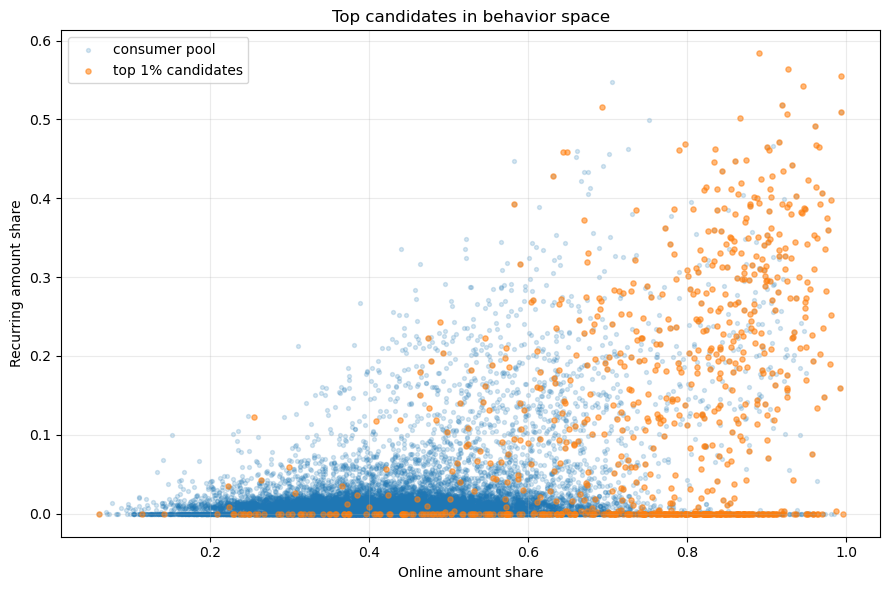

In [27]:
behavior_check_features = [
    "total_amount_kzt",
    "amount_per_active_day_kzt",
    "online_amount_share",
    "recurring_amount_share",
    "recurring_capable_amount_share",
    "top_mcc_amount_share",
    "mcc_amount_hhi",
    "business_hours_amount_share",
    "night_amount_share",
    "monthly_amount_cv"
]

score_band_behavior = (
    final_scores
    .groupby("opportunity_band")[behavior_check_features]
    .median()
    .reset_index()
)

display(score_band_behavior)

fig, ax = plt.subplots(figsize=(9, 6))
sample_all = final_scores.sample(min(20000, len(final_scores)), random_state=RANDOM_STATE)
sample_top = final_scores[final_scores["opportunity_band"] == "Top 1% highest priority"]

ax.scatter(
    sample_all["online_amount_share"],
    sample_all["recurring_amount_share"],
    s=8,
    alpha=0.18,
    label="consumer pool"
)

ax.scatter(
    sample_top["online_amount_share"],
    sample_top["recurring_amount_share"],
    s=14,
    alpha=0.55,
    label="top 1% candidates"
)

ax.set_title("Top candidates in behavior space")
ax.set_xlabel("Online amount share")
ax.set_ylabel("Recurring amount share")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(VISUAL_FOLDER / "08_top_candidates_behavior_space.png", dpi=300, bbox_inches="tight")
plt.show()

The score-band validation shows that the highest-ranked consumer cards have stronger business-like behavior than the standard monitoring group.

The Top 1% group has higher total amount, higher online amount share, higher recurring-capable amount share, and stronger MCC concentration. In the scatter plot, many Top 1% candidates move toward the upper-right area, where online and recurring payment behavior is stronger.

This supports the final ranking result. The model is not only producing scores; the top-ranked cards also show interpretable business-like transaction patterns.

# 10. Simple Explainability: Reason Codes

The score should not be a black box.

For each cardholder we generate short reason codes based on visible behavior indicators.  
These reason codes are useful for presentation, app prototype, and human review.

In [28]:
business_medians = business_cards[selected_features].median(numeric_only=True)

def build_reasons(row):
    reasons = []

    if row["online_amount_share"] >= business_medians["online_amount_share"]:
        reasons.append("High online spending share")

    if row["recurring_amount_share"] >= business_medians["recurring_amount_share"]:
        reasons.append("High recurring payment share")

    if row["amount_per_active_day_kzt"] >= business_medians["amount_per_active_day_kzt"]:
        reasons.append("High spending intensity")

    if row["top_mcc_amount_share"] >= business_medians["top_mcc_amount_share"]:
        reasons.append("Concentrated MCC spending")

    if row["business_hours_amount_share"] >= business_medians["business_hours_amount_share"]:
        reasons.append("Business-hour spending pattern")

    if row["night_amount_share"] >= business_medians["night_amount_share"]:
        reasons.append("Night transaction pattern")

    if not reasons:
        reasons.append("Moderate business-like similarity")

    return reasons[:3]

reason_lists = final_scores.apply(build_reasons, axis=1)
final_scores["top_reason_1"] = reason_lists.apply(lambda x: x[0] if len(x) > 0 else "")
final_scores["top_reason_2"] = reason_lists.apply(lambda x: x[1] if len(x) > 1 else "")
final_scores["top_reason_3"] = reason_lists.apply(lambda x: x[2] if len(x) > 2 else "")

def recommended_action(band):
    if band == "Top 1% highest priority":
        return "First review for business card migration"
    if band == "Top 5% priority":
        return "Target with business product offer"
    if band == "Top 10% review":
        return "Review if campaign capacity allows"
    return "Monitor only"

final_scores["recommended_action"] = final_scores["opportunity_band"].apply(recommended_action)

display(final_scores.sort_values("score", ascending=False)[[
    "card_number", "score", "opportunity_band",
    "top_reason_1", "top_reason_2", "top_reason_3",
    "recommended_action"
]].head(15))

,card_number,score,opportunity_band,top_reason_1,top_reason_2,top_reason_3,recommended_action
58957,5441026331984360,0.988864,Top 1% highest priority,High spending intensity,Concentrated MCC spending,Business-hour spending pattern,First review for business card migration
6633,5119023403360653,0.987096,Top 1% highest priority,Concentrated MCC spending,Business-hour spending pattern,,First review for business card migration
12681,5176476691114937,0.981081,Top 1% highest priority,High online spending share,High recurring payment share,Night transaction pattern,First review for business card migration
16774,5176513825363681,0.914270,Top 1% highest priority,High online spending share,High recurring payment share,Night transaction pattern,First review for business card migration
7137,5119027760461624,0.876269,Top 1% highest priority,High recurring payment share,High spending intensity,Concentrated MCC spending,First review for business card migration
25695,5201491354169846,0.799206,Top 1% highest priority,High spending intensity,Concentrated MCC spending,,First review for business card migration
4187,5100616835634321,0.780084,Top 1% highest priority,High online spending share,High recurring payment share,Concentrated MCC spending,First review for business card migration
45600,5368292766350035,0.738810,Top 1% highest priority,High online spending share,High spending intensity,Concentrated MCC spending,First review for business card migration
15513,5176512396428493,0.729417,Top 1% highest priority,Business-hour spending pattern,,,First review for business card migration
56761,5438818182091724,0.675544,Top 1% highest priority,High online spending share,High recurring payment share,High spending intensity,First review for business card migration


# 11. Save Final Outputs

The technical submission file is:

```text
outputs/submission_card_scores.csv
```

It contains only:

```text
card_number, score
```

Additional files are saved for explanation and product prototype use.

In [29]:
submission = final_scores[["card_number", "score"]].copy()
submission = submission.sort_values("card_number").reset_index(drop=True)

submission_path = OUTPUT_FOLDER / "submission_card_scores.csv"
detail_path = OUTPUT_FOLDER / "final_cardholder_scoring_table.csv"
features_path = OUTPUT_FOLDER / "feature_evidence_and_justification.csv"
band_path = OUTPUT_FOLDER / "score_band_summary.csv"
model_path = OUTPUT_FOLDER / "heis_repeated_pu_hgb_models.joblib"

submission.to_csv(submission_path, index=False)
final_scores.to_csv(detail_path, index=False)
band_summary.to_csv(band_path, index=False)
joblib.dump(pu_models, model_path)

print("Saved final outputs:")
print(submission_path)
print(detail_path)
print(features_path)
print(band_path)
print(model_path)

display(submission.head())
print("Submission rows:", len(submission))
print("Unique cards:", submission["card_number"].nunique())
print("Score range:", submission["score"].min(), "to", submission["score"].max())

Saved final outputs:
C:\Users\balal\Desktop\MaterCradCase\outputs\submission_card_scores.csv
C:\Users\balal\Desktop\MaterCradCase\outputs\final_cardholder_scoring_table.csv
C:\Users\balal\Desktop\MaterCradCase\outputs\feature_evidence_and_justification.csv
C:\Users\balal\Desktop\MaterCradCase\outputs\score_band_summary.csv
C:\Users\balal\Desktop\MaterCradCase\outputs\heis_repeated_pu_hgb_models.joblib


,card_number,score
0,5100610005930965,0.002625
1,5100610005962109,0.000118
2,5100610007285137,0.000118
3,5100610011916156,0.000118
4,5100610012043588,0.000118


Submission rows: 80000
Unique cards: 80000
Score range: 0.00010809705482418366 to 0.9888640257468154


# 12. Final Notes and Limitations

This solution is designed as a realistic and responsible business-ranking system, not as a black-box hard classifier.

The strongest part of the approach is that the prediction is made at the **cardholder level**, which matches the real business problem. The notebook first studies the raw transaction data, then proves feature usefulness through descriptive and diagnostic EDA before model training. The final features are linked to clear business behavior: spending intensity, payment channel, recurring usage, merchant/MCC concentration, and time patterns.

The model also follows a Positive-Unlabeled ranking approach. This is important because consumer cards are not confirmed negative cases. Some consumer cards may actually contain hidden business-like behavior. For this reason, the model does not simply classify consumers as “not business.” Instead, it produces a business-likeness score and ranks cardholders by opportunity level.

The repeated sampling strategy makes the score more stable. Instead of depending on one sampled consumer comparison group, the model trains several times and averages the results. This reduces sampling risk and gives a more reliable final ranking.

The main limitation is that the true hidden-business labels in the consumer portfolio are not available to participants. Therefore, internal validation is proxy validation: it checks whether the model can separate held-out known business cards from sampled consumer comparison cards. The final score should be used as a prioritization signal for business review, not as legal proof that a cardholder owns a business.

For production use, the model should be improved through a feedback loop. Banks and business teams can review top-score bands, track product acceptance, collect sales outcomes, and use this feedback to recalibrate the model. Over time, the system can become stronger by learning from real conversion results and human review decisions.

The recommended next step is to use the Top 1%, Top 5%, and Top 10% score bands for controlled business review. After feedback is collected, the model should be retrained and calibrated using real business outcomes.